Univariate imputation---> 

when there is some missing value in a cell of a col then if that missing value is filled by the mean of other values of the same col then its univariate

Multivariate imputation-->

when there is some missing value in a cell of a col then bija cols ni value na help thi aene fill karye to bivariate/multivariate and for multivariate-- knn and iterative 2 waya

here we will use mean/median aribitary end of distribution randomly for univariate

## Mean median

for uniform or normal distribution data mean is used
and for skewed median is used

## benifits of mean and media

1. Simple(code pr b and server pr b recreate or reuse is easier)
2. 5 percent thi less ma j it works properly so we dont use it in production

## Disadv

1. Distribution na shape ne change kari de(pdf)
2. Outliers aavi jay j pehla original data ma nata so system detects those fake outliers
3. Covariance / correlation ma chnages

THERE ARE MAJOR DISADV SO WE DONT USE IT

## WHEN to use
1. missing at random
2. missing less than 5 percent

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [2]:
df = pd.read_csv('titanic_toy.csv')

In [3]:
df.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [4]:
df.isnull().mean()

Age         0.198653
Fare        0.050505
Family      0.000000
Survived    0.000000
dtype: float64

In [5]:
X=df.drop(columns=['Survived'])
y=df['Survived']

In [6]:
X_train,X_test,y_train,y_est = train_test_split(X,y,test_size=0.2,random_state=2)

In [7]:
X_train.shape,X_test.shape

((712, 3), (179, 3))

In [8]:
X_train.isnull().mean()

Age       0.207865
Fare      0.050562
Family    0.000000
dtype: float64

In [9]:
median_age = X_train['Age'].median()
mean_age = X_train['Age'].mean()
median_fare = X_train['Fare'].median()
mean_fare = X_train['Fare'].mean()

In [10]:
X_train['Age_median'] = X_train['Age'].fillna(median_age)
X_train['Age_mean'] = X_train['Age'].fillna(mean_age)

X_train['Fare_median'] = X_train['Fare'].fillna(median_fare)
X_train['Fare_mean'] = X_train['Fare'].fillna(mean_fare)

In [11]:
print('Original Age variable variance: ', X_train['Age'].var())
print('Age Variance after median imputation: ', X_train['Age_median'].var())
print('Age Variance after mean imputation: ', X_train['Age_mean'].var())

print('Original Fare variable variance: ', X_train['Fare'].var())
print('Fare Variance after median imputation: ', X_train['Fare_median'].var())
print('Fare Variance after mean imputation: ', X_train['Fare_mean'].var())

# .var() used to know that original data thi ketlu deviate thyu

Original Age variable variance:  204.34951339046142
Age Variance after median imputation:  161.98956633460548
Age Variance after mean imputation:  161.81262452718676
Original Fare variable variance:  2448.1979137063163
Fare Variance after median imputation:  2340.09102197536
Fare Variance after mean imputation:  2324.2385256705534


<Axes: ylabel='Density'>

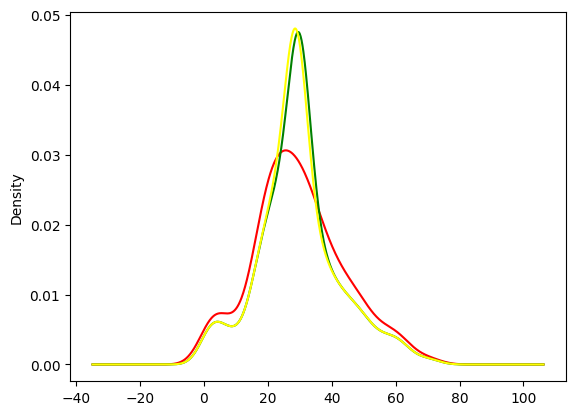

In [12]:
fig = plt.figure()
ax = fig.add_subplot(111)

X_train['Age'].plot.density(color='red')
X_train['Age_mean'].plot.density(color='green')
X_train['Age_median'].plot.density(color='yellow')

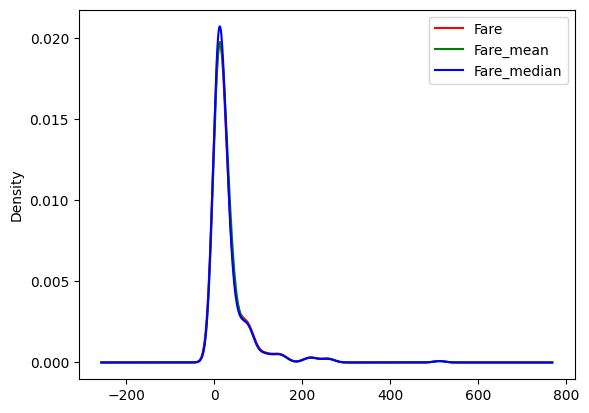

In [13]:
fig = plt.figure()
ax=fig.add_subplot(111)

X_train['Fare'].plot.density(color='red')
X_train['Fare_mean'].plot.density(color='green')
X_train['Fare_median'].plot.density(color='blue')

lines,labels = ax.get_legend_handles_labels()
ax.legend()

<Axes: >

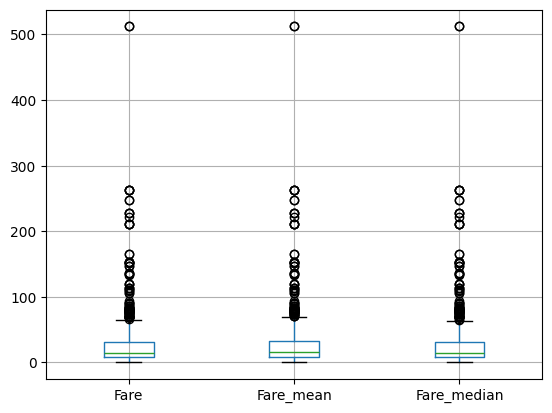

In [14]:
X_train[['Fare','Fare_mean','Fare_median']].boxplot()

<Axes: >

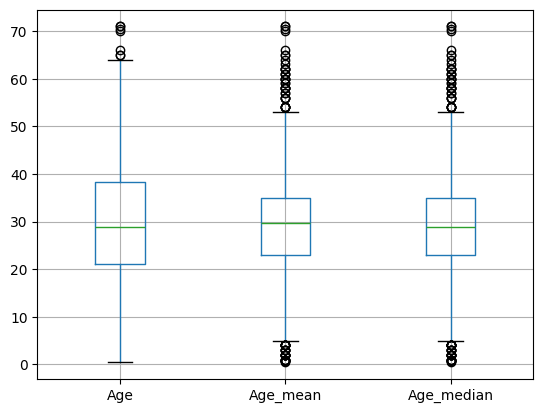

In [15]:
X_train[['Age','Age_mean','Age_median']].boxplot()

cov/covariance is the interaction of one col with other cols so that shouldnt change
corr pn same kare but aema tamne chote changes dekhay as it lies b/w -1 and 1 and cov ma no limit

In [16]:
X_train.cov()

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
Age,204.349513,70.719262,-6.498901,204.349513,204.349513,64.858859,66.665205
Fare,70.719262,2448.197914,17.258917,57.957599,55.603719,2448.197914,2448.197914
Family,-6.498901,17.258917,2.735252,-5.112563,-5.146106,16.476305,16.385048
Age_median,204.349513,57.957599,-5.112563,161.989566,161.812625,53.553455,55.023037
Age_mean,204.349513,55.603719,-5.146106,161.812625,161.812625,51.358000,52.788341
Fare_median,64.858859,2448.197914,16.476305,53.553455,51.358000,2340.091022,2324.238526
Fare_mean,66.665205,2448.197914,16.385048,55.023037,52.788341,2324.238526,2324.238526


In [17]:
X_train.corr()

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
Age,1.000000,0.092644,-0.299113,1.000000,1.000000,0.087356,0.090156
Fare,0.092644,1.000000,0.208268,0.091757,0.088069,1.000000,1.000000
Family,-0.299113,0.208268,1.000000,-0.242883,-0.244610,0.205942,0.205499
Age_median,1.000000,0.091757,-0.242883,1.000000,0.999454,0.086982,0.089673
Age_mean,1.000000,0.088069,-0.244610,0.999454,1.000000,0.083461,0.086078
Fare_median,0.087356,1.000000,0.205942,0.086982,0.083461,1.000000,0.996607
Fare_mean,0.090156,1.000000,0.205499,0.089673,0.086078,0.996607,1.000000


## Conclusion --> fare mate mean,median karay age mate na karay

## SKLEARN

sklearn aj use karay but aeno code is more difficult and ae output aapde np arr ma

In [18]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=2)

In [19]:
imputer1 = SimpleImputer()
imputer2 = SimpleImputer(strategy='median')

In [21]:
trf=ColumnTransformer([
    ('imputer1',imputer1,['Age']),
    ('imputer2',imputer2,['Fare'])
],remainder='passthrough')

In [22]:
trf.fit(X_train)

,transformers,"[('imputer1', ...), ('imputer2', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'mean'
,fill_value,None


In [23]:
trf.named_transformers_['imputer1'].statistics_

array([29.78590426])

In [24]:
trf.named_transformers_['imputer2'].statistics_

array([14.4583])

In [25]:
X_train = trf.transform(X_train)
X_test = trf.transform(X_test)

In [26]:
X_train

array([[ 40.        ,  27.7208    ,   0.        ],
       [  4.        ,  16.7       ,   2.        ],
       [ 47.        ,   9.        ,   0.        ],
       ...,
       [ 71.        ,  49.5042    ,   0.        ],
       [ 29.78590426, 221.7792    ,   0.        ],
       [ 29.78590426,  25.925     ,   0.        ]], shape=(712, 3))